# SERL (UKDA 8963) quick explorer + ABM calibration targets

Goal: get a visual feel for what's in the SERL aggregated statistics release, then transform it into tidy target tables we can calibrate the ABM against.

Reads from: `../data/UKDA-8963-csv/csv/`
Writes (CSV) to: `../data/serl_8963_targets/`


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True


In [34]:
# ---- Paths ----
DATA_DIR = Path("../data").resolve()
SERL_CSV_DIR = DATA_DIR / "UKDA-8963-csv" / "csv"
OUT_DIR = DATA_DIR / "serl_8963_targets"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DAILY_CSV = SERL_CSV_DIR / "serl_daily_energy_use_in_gb_domestic_buildings_2020_to_2023_aggregated_statistics.csv"
HH_CSVS = {
    2020: SERL_CSV_DIR / "serl_half_hourly_energy_use_in_gb_domestic_buildings_2020_aggregated_statistics.csv",
    2021: SERL_CSV_DIR / "serl_half_hourly_energy_use_in_gb_domestic_buildings_2021_aggregated_statistics.csv",
    2022: SERL_CSV_DIR / "serl_half_hourly_energy_use_in_gb_domestic_buildings_2022_aggregated_statistics.csv",
    2023: SERL_CSV_DIR / "serl_half_hourly_energy_use_in_gb_domestic_buildings_2023_aggregated_statistics.csv",
}

assert DAILY_CSV.exists(), f"Missing: {DAILY_CSV}"
for y, p in HH_CSVS.items():
    assert p.exists(), f"Missing: {p}"

print("SERL daily:", DAILY_CSV)
print("SERL half-hourly years:", sorted(HH_CSVS))
print("Output dir:", OUT_DIR)


SERL daily: /Users/abeltran/Documents/GitHub/spdt_abm/data/UKDA-8963-csv/csv/serl_daily_energy_use_in_gb_domestic_buildings_2020_to_2023_aggregated_statistics.csv
SERL half-hourly years: [2020, 2021, 2022, 2023]
Output dir: /Users/abeltran/Documents/GitHub/spdt_abm/data/serl_8963_targets


In [35]:
# ---- Helpers ----
SERL_COLS = [
    "quantity","unit","summary_time","aggregation_period","weekday_weekend",
    "segmentation_variable_1","segment_1_value",
    "segmentation_variable_2","segment_2_value",
    "segmentation_variable_3","segment_3_value",
    "mean","standard_deviation","standard_error_mean","median",
    "25th_percentile","75th_percentile",
    "mean_temp","mean_hdd","mean_solar","n_rounded",
]

NUM_COLS = [
    "mean","standard_deviation","standard_error_mean","median",
    "25th_percentile","75th_percentile",
    "mean_temp","mean_hdd","mean_solar","n_rounded",
]


def _parse_period(ap: pd.Series) -> pd.DataFrame:
    ap_str = ap.astype("string").fillna("").str.strip()
    is_annual = ap_str.str.match(r"^\d{4}$")
    is_monthly = ap_str.str.match(r"^\d{4}-\d{2}$")

    year = pd.to_numeric(ap_str.str.slice(0, 4), errors="coerce").astype("Int64")
    month = pd.to_numeric(ap_str.str.slice(5, 7), errors="coerce").astype("Int64")
    month = month.where(is_monthly, pd.NA)

    period_type = pd.Series(pd.NA, index=ap_str.index, dtype="string")
    period_type[is_annual] = "annual"
    period_type[is_monthly] = "monthly"

    return pd.DataFrame({"period": ap_str, "period_type": period_type, "year": year, "month": month})


def _read_serl_csv(path: Path) -> pd.DataFrame:
    dtypes = {
        "quantity": "category",
        "unit": "category",
        "summary_time": "category",
        "aggregation_period": "string",
        "weekday_weekend": "category",
        "segmentation_variable_1": "category",
        "segment_1_value": "category",
        "segmentation_variable_2": "category",
        "segment_2_value": "category",
        "segmentation_variable_3": "category",
        "segment_3_value": "category",
    }
    df = pd.read_csv(path, usecols=SERL_COLS, dtype=dtypes, low_memory=False)

    df["segmentation_variable_3"] = (
        df["segmentation_variable_3"].astype("string").fillna("").str.strip().replace({"": "none"})
    )
    df["segment_3_value"] = (
        df["segment_3_value"].astype("string").fillna("").str.strip().replace({"": "none"})
    )

    for c in NUM_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    period_df = _parse_period(df["aggregation_period"])
    df = pd.concat([df.drop(columns=["aggregation_period"]), period_df], axis=1)
    return df


def _pretty_counts(df: pd.DataFrame, col: str, n: int = 20) -> pd.DataFrame:
    vc = df[col].astype("string").fillna("(NA)").value_counts(dropna=False).head(n)
    return vc.rename_axis(col).reset_index(name="rows")


def _hhmm_to_hour(s: pd.Series) -> pd.Series:
    return s.astype(str).str.slice(0, 2).astype(int)


def to_hourly_mean_from_halfhour(diurnal_hh: pd.DataFrame) -> pd.DataFrame:
    out = diurnal_hh.copy()
    out = out[out["summary_time"].astype(str).str.match(r"^\d{2}:\d{2}$")].copy()
    out["hour"] = _hhmm_to_hour(out["summary_time"])

    keys = [
        "quantity","unit","weekday_weekend",
        "segmentation_variable_1","segment_1_value",
        "segmentation_variable_2","segment_2_value",
        "segmentation_variable_3","segment_3_value",
        "period","period_type","year","hour",
    ]

    hourly = out.groupby(keys, as_index=False, observed=True).agg({
        "mean": "sum",
        "mean_temp": "mean",
        "mean_hdd": "mean",
        "mean_solar": "mean",
        "n_rounded": "min",
    })
    hourly["mean_kwh"] = hourly["mean"] / 1000.0
    return hourly


In [36]:
# ---- Load daily + half-hourly ----
daily = _read_serl_csv(DAILY_CSV)
print("daily rows:", len(daily))

hh_frames = []
for year, path in HH_CSVS.items():
    df = _read_serl_csv(path)
    df["period"] = str(year)
    df["period_type"] = "annual"
    df["year"] = int(year)
    df["month"] = pd.NA
    hh_frames.append(df)

hh = pd.concat(hh_frames, ignore_index=True)
print("half-hourly rows:", len(hh))


daily rows: 531180
half-hourly rows: 1961280


## Inventory tables

In [37]:
display(_pretty_counts(daily, "quantity"))
display(_pretty_counts(daily, "unit"))
display(_pretty_counts(daily, "weekday_weekend"))
display(_pretty_counts(daily, "segmentation_variable_3"))


,quantity,rows
0,Gas,106236
1,Electricity imports,106236
2,Electricity net,106236
3,Electricity exports,106236
4,Gas + electricity imports,106236


,unit,rows
0,kWh/day,177060
1,kWh/m2/day,177060
2,kWh/person/day,177060


,weekday_weekend,rows
0,both,517140
1,weekend,7020
2,weekday,7020


,segmentation_variable_3,rows
0,region,77220
1,building_age,56160
2,num_occupants,49140
3,num_bedrooms,42120
4,building_type,42120
5,tenure,42120
6,temperature_band,42120
7,IMD_quintile,35100
8,currentEnergyRating,35100
9,floor_area_m2,35100


In [38]:
print("daily period_type counts:", daily["period_type"].value_counts(dropna=False))
print("years:", sorted(daily["year"].dropna().astype(int).unique().tolist()))


daily period_type counts: period_type
monthly    490320
annual      40860
Name: count, dtype: Int64
years: [2020, 2021, 2022, 2023]


## Quick visuals

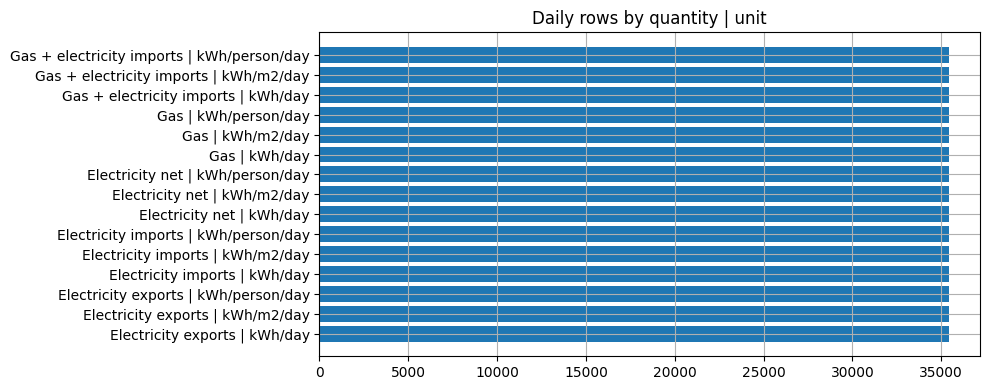

In [39]:
# Rows by quantity x unit (daily)
piv = (daily.assign(quantity=daily["quantity"].astype(str), unit=daily["unit"].astype(str))
       .groupby(["quantity","unit"], as_index=False)
       .size()
       .rename(columns={"size":"rows"}))

fig, ax = plt.subplots()
ax.barh(piv["quantity"] + " | " + piv["unit"], piv["rows"])
ax.set_title("Daily rows by quantity | unit")
plt.tight_layout()
plt.show()


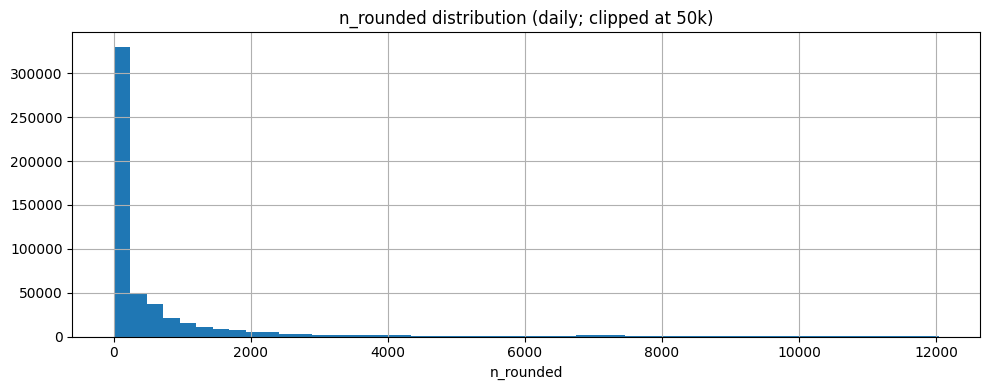

In [40]:
# n_rounded distribution (daily)
fig, ax = plt.subplots()
daily["n_rounded"].dropna().clip(upper=50000).hist(bins=50, ax=ax)
ax.set_title("n_rounded distribution (daily; clipped at 50k)")
ax.set_xlabel("n_rounded")
plt.tight_layout()
plt.show()


## Build calibration targets (CSV)

In [41]:
DAILY_Q = ["Electricity imports", "Gas"]
daily_targets = daily[(daily["unit"].astype(str) == "kWh/day") & (daily["quantity"].isin(DAILY_Q))].copy()

daily_targets = daily_targets.rename(columns={
    "25th_percentile": "p25",
    "75th_percentile": "p75",
    "standard_deviation": "sd",
    "standard_error_mean": "se",
})

daily_targets["heating_fuel"] = daily_targets["segment_1_value"].astype(str)
daily_targets["has_pv"] = daily_targets["segment_2_value"].astype(str)
daily_targets["seg3_var"] = daily_targets["segmentation_variable_3"].astype("string")
daily_targets["seg3_value"] = daily_targets["segment_3_value"].astype("string")

keep = [
    "quantity","unit","period","period_type","year","month","weekday_weekend",
    "heating_fuel","has_pv","seg3_var","seg3_value",
    "mean","median","p25","p75","sd","se","n_rounded",
    "mean_temp","mean_hdd","mean_solar",
]

daily_targets = daily_targets[keep].copy()
print("daily_targets rows:", len(daily_targets))
daily_targets.head(3)


daily_targets rows: 70824


,quantity,unit,period,period_type,year,month,weekday_weekend,heating_fuel,has_pv,seg3_var,...,mean,median,p25,p75,sd,se,n_rounded,mean_temp,mean_hdd,mean_solar
0,Gas,kWh/day,2020,annual,2020,<NA>,both,Gas,Yes,none,...,38.011883,35.515,24.441,46.909,21.910751,1.589573,190,11.058583,5.113639,126.331896
1,Gas,kWh/day,2020,annual,2020,<NA>,both,Gas,No,none,...,36.756555,32.734,22.264,46.324,21.739424,0.433060,2520,11.011278,5.170542,125.856741
2,Gas,kWh/day,2020,annual,2020,<NA>,both,Gas,All,none,...,36.845128,32.859,22.414,46.407,21.749859,0.417803,2710,11.014616,5.166527,125.890267


In [42]:
out_daily = OUT_DIR / "daily_targets.csv"
daily_targets.to_csv(out_daily, index=False)
print("Wrote:", out_daily)


Wrote: /Users/abeltran/Documents/GitHub/spdt_abm/data/serl_8963_targets/daily_targets.csv


In [43]:
HH_Q = ["Electricity imports", "Gas"]
hh_targets = hh[(hh["unit"].astype(str) == "Wh") & (hh["quantity"].isin(HH_Q))].copy()

hourly_mean = to_hourly_mean_from_halfhour(hh_targets)

hourly_mean["heating_fuel"] = hourly_mean["segment_1_value"].astype(str)
hourly_mean["has_pv"] = hourly_mean["segment_2_value"].astype(str)
hourly_mean["seg3_var"] = hourly_mean["segmentation_variable_3"].astype("string")
hourly_mean["seg3_value"] = hourly_mean["segment_3_value"].astype("string")

keep_hr = [
    "quantity","unit","year","weekday_weekend","heating_fuel","has_pv","seg3_var","seg3_value",
    "hour","mean_kwh","mean_temp","mean_solar","n_rounded",
]

hourly_mean_out = hourly_mean[keep_hr].copy()
print("hourly_mean_out rows:", len(hourly_mean_out))
hourly_mean_out.head(3)


hourly_mean_out rows: 130752


,quantity,unit,year,weekday_weekend,heating_fuel,has_pv,seg3_var,seg3_value,hour,mean_kwh,mean_temp,mean_solar,n_rounded
0,Electricity imports,Wh,2020,both,All,All,IMD_quintile,1,0,0.305655,9.612746,0.0,620
1,Electricity imports,Wh,2020,both,All,All,IMD_quintile,1,1,0.263687,9.378751,0.0,620
2,Electricity imports,Wh,2020,both,All,All,IMD_quintile,1,2,0.237819,9.160208,0.0,620


In [44]:
out_hr = OUT_DIR / "diurnal_targets_hourly_mean.csv"
hourly_mean_out.to_csv(out_hr, index=False)
print("Wrote:", out_hr)


Wrote: /Users/abeltran/Documents/GitHub/spdt_abm/data/serl_8963_targets/diurnal_targets_hourly_mean.csv


## ABM-like plots

In [45]:
# Plot helpers

def plot_diurnal_by_seg3(
    df,
    *,
    year=2023,
    quantity="Electricity imports",
    heating_fuel="All",
    has_pv="No",
    weekday="both",
    seg3_var="num_occupants",
    max_lines=8,
):
    sub = df[
        (df["year"] == year)
        & (df["weekday_weekend"].astype(str) == weekday)
        & (df["quantity"].astype(str) == quantity)
        & (df["heating_fuel"].astype(str) == heating_fuel)
        & (df["has_pv"].astype(str) == has_pv)
        & (df["seg3_var"].astype(str) == seg3_var)
    ].copy()

    if sub.empty:
        print("No rows for that filter.")
        print(
            "Try seg3_var from:",
            sorted(df["seg3_var"].astype(str).unique().tolist())[:20],
        )
        return

    keep_vals = (
        sub.groupby("seg3_value", observed=True)["n_rounded"]
        .max()
        .sort_values(ascending=False)
        .head(max_lines)
        .index
    )
    sub = sub[sub["seg3_value"].isin(keep_vals)].copy()

    fig, ax = plt.subplots(figsize=(10, 4))
    for v, g in sub.groupby("seg3_value", observed=True):
        g = g.sort_values("hour")
        ax.plot(g["hour"], g["mean_kwh"], marker="o", label=str(v))

    ax.set_xticks(range(0, 24, 2))
    ax.set_title(
        f"Diurnal hourly mean ({year}) - {quantity} | fuel={heating_fuel} | PV={has_pv} | {seg3_var}"
    )
    ax.set_xlabel("hour")
    ax.set_ylabel("kWh/hour")
    ax.legend(title=seg3_var, ncols=2, fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_diurnal_by_year(
    df,
    *,
    quantity="Electricity imports",
    heating_fuel="All",
    has_pv="No",
    weekday="both",
    seg3_var="none",
    seg3_value="none",
):
    sub = df[
        (df["weekday_weekend"].astype(str) == weekday)
        & (df["quantity"].astype(str) == quantity)
        & (df["heating_fuel"].astype(str) == heating_fuel)
        & (df["has_pv"].astype(str) == has_pv)
        & (df["seg3_var"].astype(str) == seg3_var)
        & (df["seg3_value"].astype(str) == seg3_value)
    ].copy()

    if sub.empty:
        print("No rows for that filter.")
        return

    fig, ax = plt.subplots(figsize=(10, 4))
    for y, g in sub.groupby("year", observed=True):
        g = g.sort_values("hour")
        ax.plot(g["hour"], g["mean_kwh"], marker="o", label=str(y))

    ax.set_xticks(range(0, 24, 2))
    ax.set_title(
        f"Diurnal hourly mean across years - {quantity} | fuel={heating_fuel} | PV={has_pv} | {seg3_var}={seg3_value}"
    )
    ax.set_xlabel("hour")
    ax.set_ylabel("kWh/hour")
    ax.legend(title="year")
    plt.tight_layout()
    plt.show()


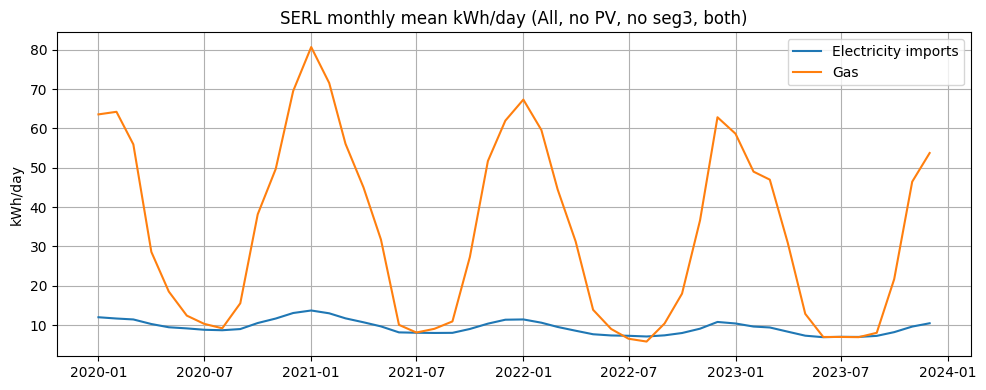

In [46]:
# Monthly mean kWh/day for a baseline group (All, no PV, no seg3)
base = daily_targets[(daily_targets["weekday_weekend"].astype(str) == "both")
                    & (daily_targets["heating_fuel"].astype(str) == "All")
                    & (daily_targets["has_pv"].astype(str) == "No")
                    & ((daily_targets["seg3_var"].astype(str) == "none"))].copy()

monthly = base[base["period_type"].astype(str) == "monthly"].copy()
fig, ax = plt.subplots()
for q in ["Electricity imports", "Gas"]:
    sub = monthly[monthly["quantity"].astype(str) == q].copy()
    sub["ym"] = pd.to_datetime(sub["period"].astype(str) + "-01", errors="coerce")
    sub = sub.sort_values("ym")
    ax.plot(sub["ym"], sub["mean"], label=q)
ax.set_title("SERL monthly mean kWh/day (All, no PV, no seg3, both)")
ax.set_ylabel("kWh/day")
ax.legend()
plt.tight_layout()
plt.show()


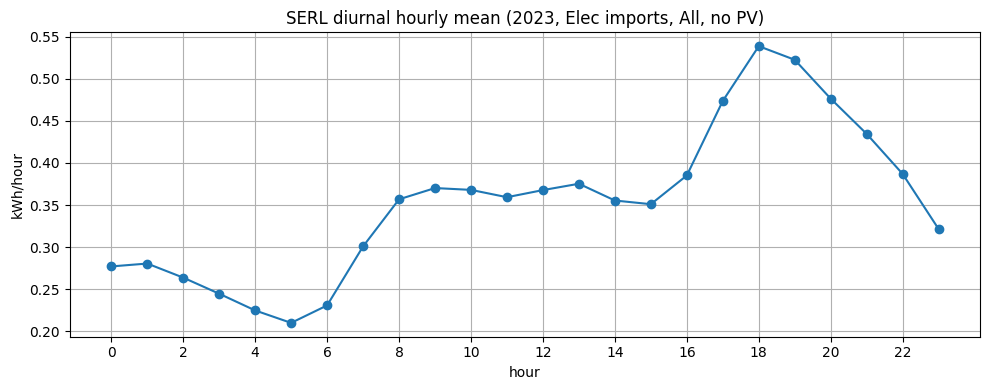

In [47]:
# Diurnal hourly mean profile for electricity imports
prof = hourly_mean_out[(hourly_mean_out["year"] == 2023)
                      & (hourly_mean_out["weekday_weekend"].astype(str) == "both")
                      & (hourly_mean_out["quantity"].astype(str) == "Electricity imports")
                      & (hourly_mean_out["heating_fuel"].astype(str) == "All")
                      & (hourly_mean_out["has_pv"].astype(str) == "No")
                      & ((hourly_mean_out["seg3_var"].astype(str) == "none"))].sort_values("hour")

fig, ax = plt.subplots()
ax.plot(prof["hour"], prof["mean_kwh"], marker="o")
ax.set_xticks(range(0, 24, 2))
ax.set_title("SERL diurnal hourly mean (2023, Elec imports, All, no PV)")
ax.set_xlabel("hour")
ax.set_ylabel("kWh/hour")
plt.tight_layout()
plt.show()


## Optional: wide shape matrix for PCA/NMF

In [48]:
shape_src = hourly_mean_out[(hourly_mean_out["weekday_weekend"].astype(str) == "both")
                           & (hourly_mean_out["has_pv"].astype(str) == "No")
                           & (hourly_mean_out["quantity"].astype(str) == "Electricity imports")].copy()

key_cols = ["year","heating_fuel","seg3_var","seg3_value"]
wide = shape_src.pivot_table(index=key_cols, columns="hour", values="mean_kwh", aggfunc="mean").sort_index(axis=1)
wide_shape = wide.div(wide.sum(axis=1).replace({0: np.nan}), axis=0)
wide_shape.columns = [f"h{int(c):02d}" for c in wide_shape.columns]
wide_shape = wide_shape.reset_index()

out_shape = OUT_DIR / "diurnal_hourly_shape_wide.csv"
wide_shape.to_csv(out_shape, index=False)
print("Wrote:", out_shape)
wide_shape.head(3)


Wrote: /Users/abeltran/Documents/GitHub/spdt_abm/data/serl_8963_targets/diurnal_hourly_shape_wide.csv


,year,heating_fuel,seg3_var,seg3_value,h00,h01,h02,h03,h04,h05,...,h14,h15,h16,h17,h18,h19,h20,h21,h22,h23
0,2020,All,IMD_quintile,1,0.032881,0.028385,0.025556,0.024805,0.023426,0.022333,...,0.044868,0.044529,0.050007,0.059761,0.064389,0.062392,0.056704,0.051856,0.045323,0.038377
1,2020,All,IMD_quintile,2,0.030461,0.025637,0.023127,0.021332,0.020358,0.021036,...,0.046425,0.045170,0.049165,0.059350,0.065941,0.063236,0.059195,0.053492,0.046361,0.037842
2,2020,All,IMD_quintile,3,0.028919,0.024939,0.023179,0.022337,0.021414,0.022242,...,0.044532,0.043763,0.047661,0.058798,0.066334,0.063729,0.057337,0.051852,0.045860,0.037037


## Marginal targets: visuals for each segmentation_3 variable

The SERL release only provides one `seg3_var` at a time (plus heating fuel + PV). So we treat these as **marginal targets**.

These plots help you see how hourly, monthly and annual consumption varies across the categories available within each `seg3_var`.


In [49]:
# Build a tidy hourly_mean_out if it doesn't exist (safe to re-run)
# (Assumes you already executed the earlier cells that define `hourly_mean_out`.)
assert 'hourly_mean_out' in globals(), "Run the earlier cells first to create hourly_mean_out"
assert 'daily_targets' in globals(), "Run the earlier cells first to create daily_targets"

print('hourly_mean_out rows', len(hourly_mean_out))
print('daily_targets rows', len(daily_targets))
print('seg3_var values (hourly):', sorted(hourly_mean_out['seg3_var'].astype(str).unique().tolist())[:20])


hourly_mean_out rows 130752
daily_targets rows 70824
seg3_var values (hourly): ['IMD_quintile', 'building_age', 'building_type', 'central_heating_type', 'currentEnergyRating', 'floor_area_m2', 'has_ev', 'none', 'num_bedrooms', 'num_occupants', 'region', 'temperature_band', 'tenure']


In [50]:
def plot_hourly_profiles_for_seg3(
    *,
    year: int,
    seg3_var: str,
    quantity: str = "Electricity imports",
    heating_fuel: str = "All",
    has_pv: str = "No",
    weekday: str = "both",
    max_lines: int = 10,
    savepath: Path | None = None,
    show: bool = True,
):
    """Hourly (diurnal) mean profile by seg3 category for a given year.

    Uses `hourly_mean_out` (kWh/home/hour). Limits to top categories by `n_rounded`.
    """
    df = hourly_mean_out
    sub = df[
        (df["year"] == year)
        & (df["weekday_weekend"].astype(str) == weekday)
        & (df["quantity"].astype(str) == quantity)
        & (df["heating_fuel"].astype(str) == heating_fuel)
        & (df["has_pv"].astype(str) == has_pv)
        & (df["seg3_var"].astype(str) == seg3_var)
    ].copy()

    if sub.empty:
        print(
            "No hourly data for:",
            dict(
                year=year,
                seg3_var=seg3_var,
                quantity=quantity,
                heating_fuel=heating_fuel,
                has_pv=has_pv,
                weekday=weekday,
            ),
        )
        return None

    top_vals = (
        sub.groupby("seg3_value", observed=True)["n_rounded"]
        .max()
        .sort_values(ascending=False)
        .head(max_lines)
        .index
    )
    sub = sub[sub["seg3_value"].isin(top_vals)].copy()

    fig, ax = plt.subplots(figsize=(10, 4))
    for v, g in sub.groupby("seg3_value", observed=True):
        g = g.sort_values("hour")
        ax.plot(g["hour"], g["mean_kwh"], marker="o", label=str(v))

    ax.set_xticks(range(0, 24, 2))
    ax.set_title(
        f"Hourly mean profile ({year}) - {quantity} | fuel={heating_fuel} | PV={has_pv} | {seg3_var}"
    )
    ax.set_xlabel("hour")
    ax.set_ylabel("kWh/home/hour")
    ax.legend(title=seg3_var, ncols=2, fontsize=8)
    plt.tight_layout()

    if savepath is not None:
        savepath.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(savepath, dpi=160)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig


def plot_monthly_means_for_seg3(
    *,
    year: int,
    seg3_var: str,
    quantity: str = "Electricity imports",
    heating_fuel: str = "All",
    has_pv: str = "No",
    weekday: str = "both",
    max_lines: int = 10,
    savepath: Path | None = None,
    show: bool = True,
):
    """Monthly mean kWh/day by seg3 category within a year."""
    df = daily_targets
    sub = df[
        (df["period_type"].astype(str) == "monthly")
        & (df["year"].astype(int) == year)
        & (df["weekday_weekend"].astype(str) == weekday)
        & (df["quantity"].astype(str) == quantity)
        & (df["heating_fuel"].astype(str) == heating_fuel)
        & (df["has_pv"].astype(str) == has_pv)
        & (df["seg3_var"].astype(str) == seg3_var)
    ].copy()

    if sub.empty:
        print(
            "No monthly data for:",
            dict(
                year=year,
                seg3_var=seg3_var,
                quantity=quantity,
                heating_fuel=heating_fuel,
                has_pv=has_pv,
                weekday=weekday,
            ),
        )
        return None

    top_vals = (
        sub.groupby("seg3_value", observed=True)["n_rounded"]
        .max()
        .sort_values(ascending=False)
        .head(max_lines)
        .index
    )
    sub = sub[sub["seg3_value"].isin(top_vals)].copy()

    sub["ym"] = pd.to_datetime(sub["period"].astype(str) + "-01", errors="coerce")
    sub = sub.sort_values(["seg3_value", "ym"])

    fig, ax = plt.subplots(figsize=(10, 4))
    for v, g in sub.groupby("seg3_value", observed=True):
        ax.plot(g["ym"], g["mean"], marker="o", label=str(v))

    ax.set_title(
        f"Monthly mean kWh/day ({year}) - {quantity} | fuel={heating_fuel} | PV={has_pv} | {seg3_var}"
    )
    ax.set_ylabel("kWh/home/day")
    ax.legend(title=seg3_var, ncols=2, fontsize=8)
    plt.tight_layout()

    if savepath is not None:
        savepath.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(savepath, dpi=160)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig


def plot_annual_means_for_seg3(
    *,
    seg3_var: str,
    quantity: str = "Electricity imports",
    heating_fuel: str = "All",
    has_pv: str = "No",
    weekday: str = "both",
    max_lines: int = 10,
    savepath: Path | None = None,
    show: bool = True,
):
    """Annual mean kWh/day across 2020-2023 by seg3 category."""
    df = daily_targets
    sub = df[
        (df["period_type"].astype(str) == "annual")
        & (df["weekday_weekend"].astype(str) == weekday)
        & (df["quantity"].astype(str) == quantity)
        & (df["heating_fuel"].astype(str) == heating_fuel)
        & (df["has_pv"].astype(str) == has_pv)
        & (df["seg3_var"].astype(str) == seg3_var)
    ].copy()

    if sub.empty:
        print(
            "No annual data for:",
            dict(
                seg3_var=seg3_var,
                quantity=quantity,
                heating_fuel=heating_fuel,
                has_pv=has_pv,
                weekday=weekday,
            ),
        )
        return None

    top_vals = (
        sub.groupby("seg3_value", observed=True)["n_rounded"]
        .max()
        .sort_values(ascending=False)
        .head(max_lines)
        .index
    )
    sub = sub[sub["seg3_value"].isin(top_vals)].copy()

    fig, ax = plt.subplots(figsize=(10, 4))
    for v, g in sub.groupby("seg3_value", observed=True):
        g = g.sort_values("year")
        ax.plot(g["year"].astype(int), g["mean"], marker="o", label=str(v))

    ax.set_title(
        f"Annual mean kWh/day (2020-2023) - {quantity} | fuel={heating_fuel} | PV={has_pv} | {seg3_var}"
    )
    ax.set_xlabel("year")
    ax.set_ylabel("kWh/home/day")
    ax.legend(title=seg3_var, ncols=2, fontsize=8)
    plt.tight_layout()

    if savepath is not None:
        savepath.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(savepath, dpi=160)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig


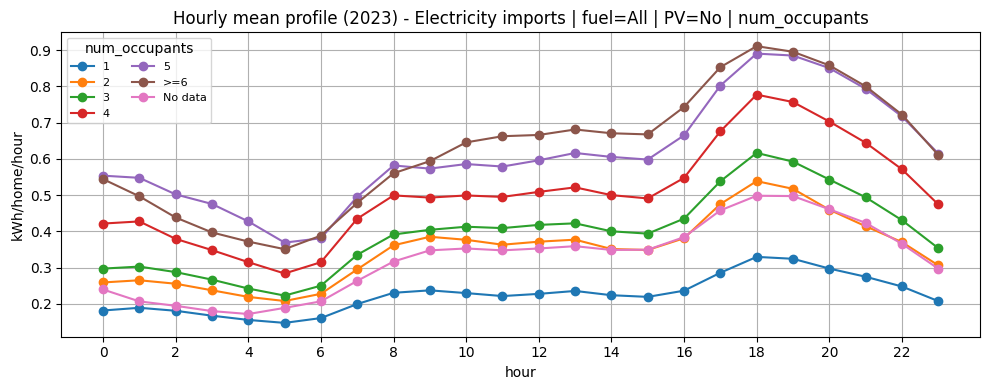

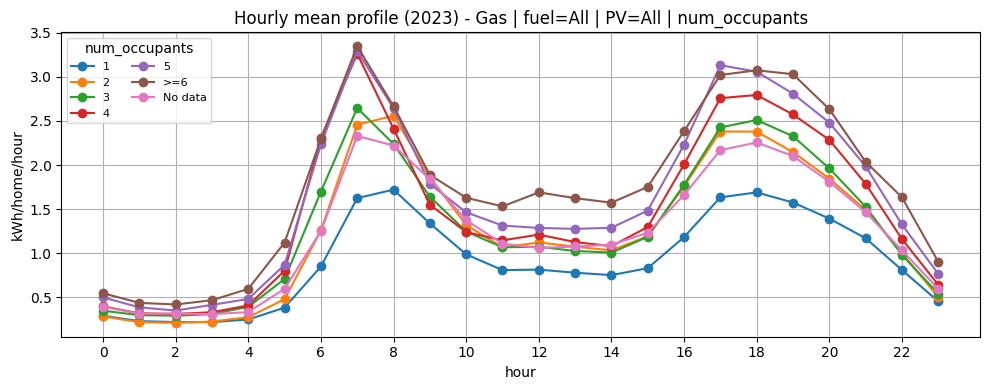

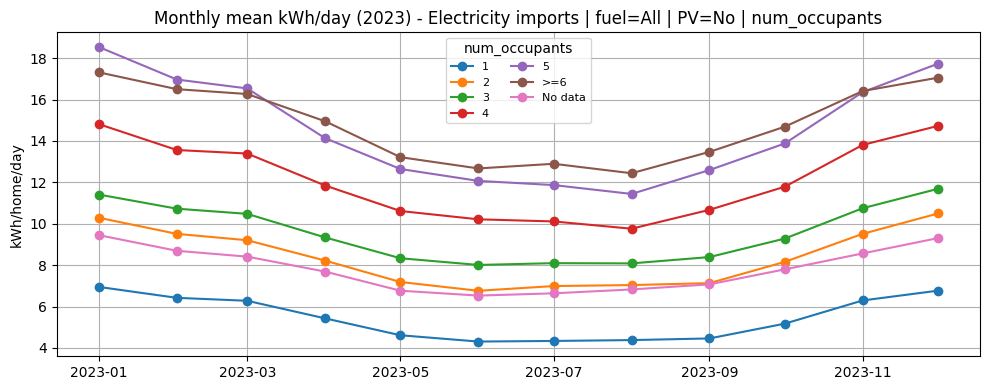

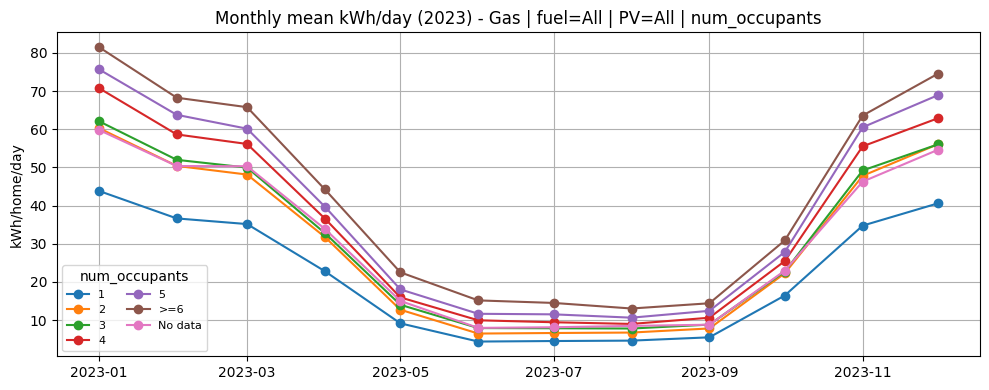

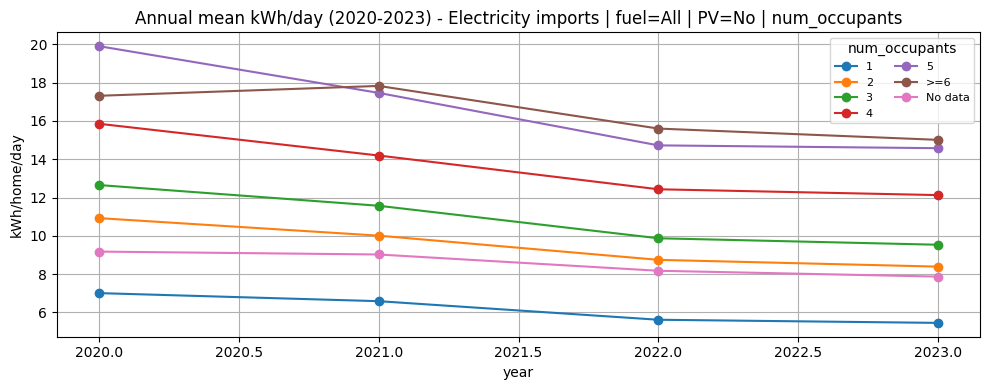

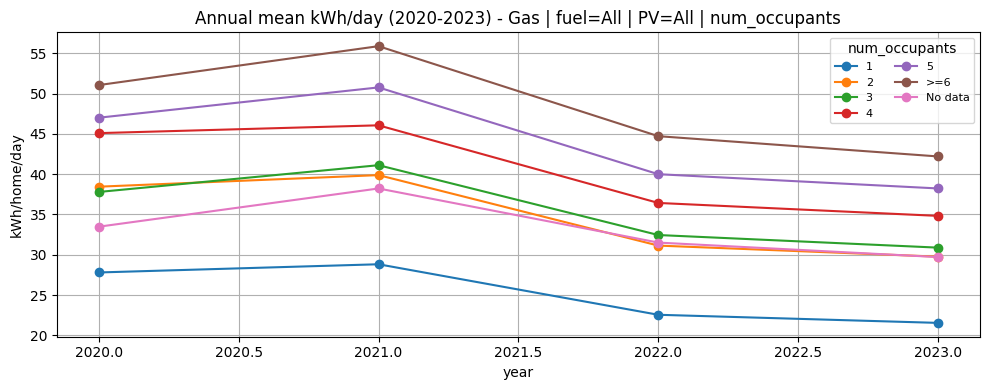

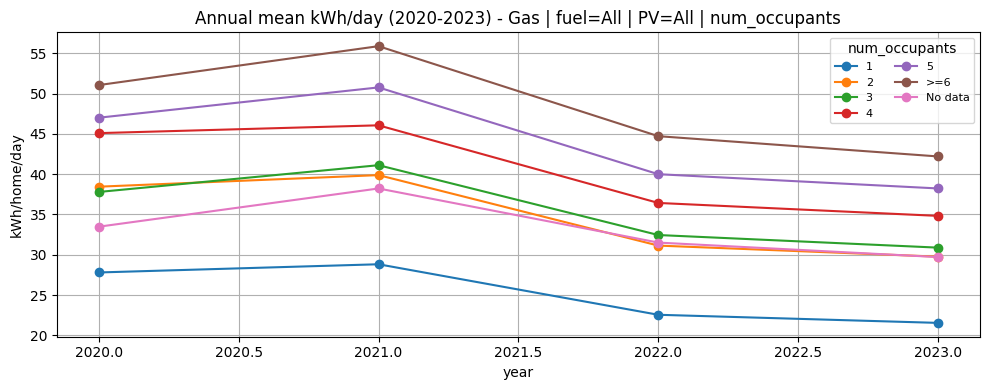

In [51]:
# Example usage (edit freely)
# For each seg3_var, you can call these three plots.

SEG3 = 'num_occupants'
YEAR = 2023

plot_hourly_profiles_for_seg3(year=YEAR, seg3_var=SEG3, quantity='Electricity imports')
plot_hourly_profiles_for_seg3(year=YEAR, seg3_var=SEG3, quantity='Gas', has_pv='All')

plot_monthly_means_for_seg3(year=YEAR, seg3_var=SEG3, quantity='Electricity imports')
plot_monthly_means_for_seg3(year=YEAR, seg3_var=SEG3, quantity='Gas', has_pv='All')

plot_annual_means_for_seg3(seg3_var=SEG3, quantity='Electricity imports')
plot_annual_means_for_seg3(seg3_var=SEG3, quantity='Gas', has_pv='All')


--- IMD_quintile ---


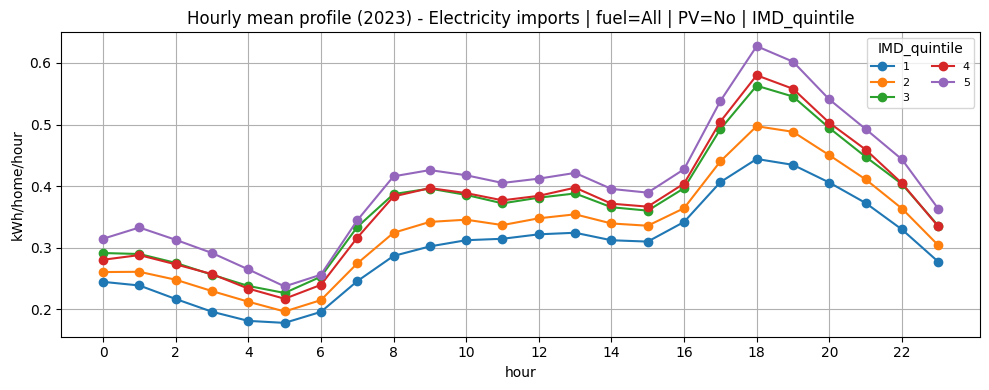

--- building_age ---


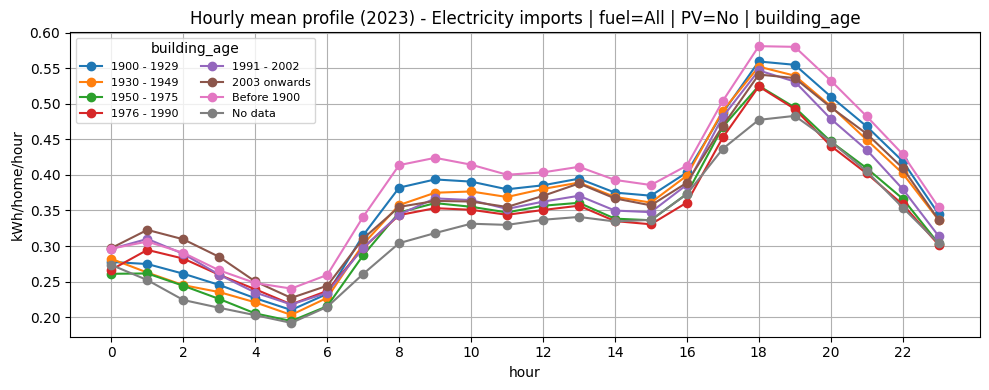

--- building_type ---


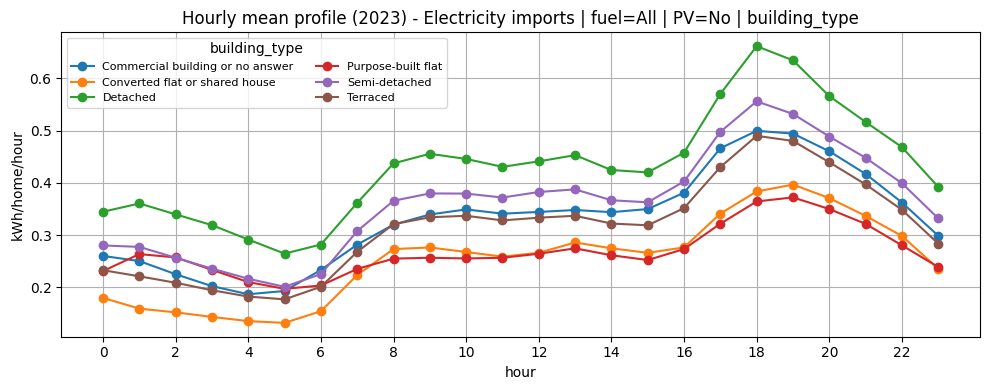

--- central_heating_type ---


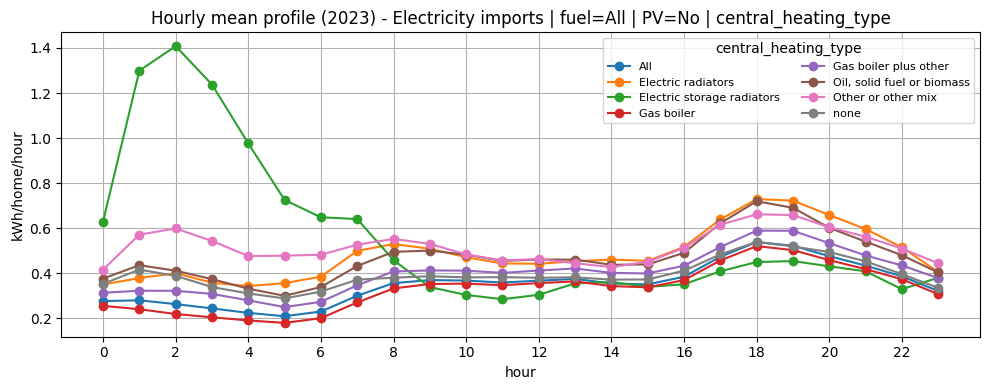

--- currentEnergyRating ---


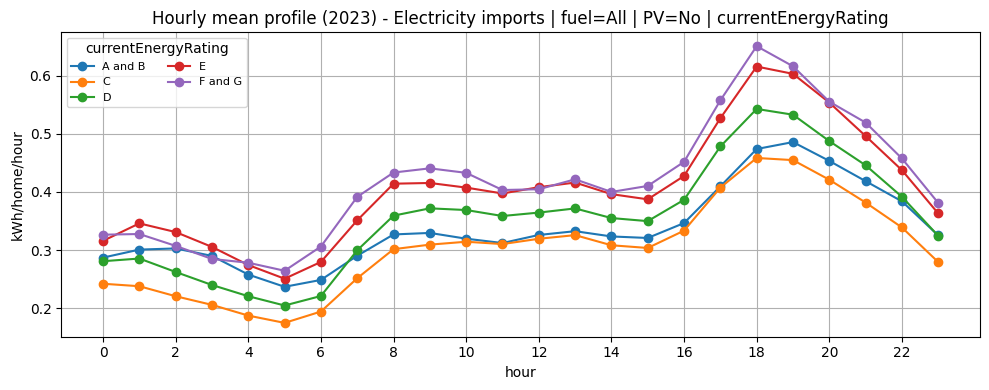

--- floor_area_m2 ---


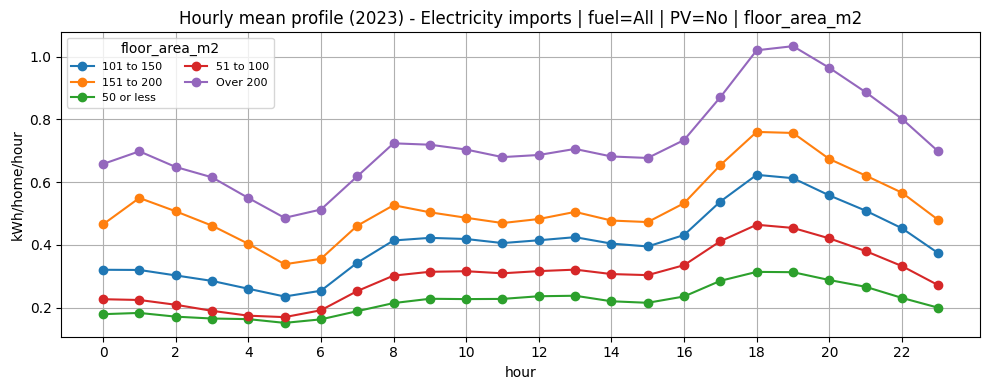

In [52]:
# Quick scan: run one hourly plot per seg3_var (electricity imports)
# This can be a lot of charts; adjust MAX_VARS or comment out.

MAX_VARS = 6
seg3_vars = [v for v in sorted(hourly_mean_out['seg3_var'].astype(str).unique().tolist()) if v not in ('none', 'nan', '<NA>')]

for v in seg3_vars[:MAX_VARS]:
    print('---', v, '---')
    plot_hourly_profiles_for_seg3(year=2023, seg3_var=v, quantity='Electricity imports', max_lines=8)


## WF experiment: match SERL marginal N and compare ABM means

`n_rounded` is the number of household summaries used to compute each SERL statistic, rounded to the nearest 10 (and set to 0 if <10).

Below we:
- map WF homes into SERL-like category labels for a chosen `seg3_var`
- stratified-sample WF homes to roughly match SERL's `n_rounded` distribution across the `seg3_value` categories
- run the ABM for a chosen year
- compare ABM vs SERL marginal means (daily scale + diurnal shape)

This is intentionally a *first-pass* check; it's not a full calibration routine yet.


In [53]:
import geopandas as gpd

# Ensure we import the *local repo* version of household_energy (not a stale installed package)
import sys, importlib
_REPO_ROOT = (Path('..').resolve())
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import household_energy.model as _hem
import household_energy.climate as _hec
importlib.reload(_hem)
importlib.reload(_hec)

EnergyModel = _hem.EnergyModel
ClimateField = _hec.ClimateField


In [54]:
# ---- WF inputs (edit if needed) ----
DATA_DIR = Path("../data").resolve()
EPC_GEOJSON = DATA_DIR / "epc_abm_waltham_forest.geojson"
HIDP_CSV = DATA_DIR / "wf_hidp_uprn_matches_tiered.csv"
CLIMATE_PARQUET = DATA_DIR / "waltham_forest_2t_timeseries_2010_2026.parquet"

assert EPC_GEOJSON.exists(), EPC_GEOJSON
assert HIDP_CSV.exists(), HIDP_CSV
assert CLIMATE_PARQUET.exists(), CLIMATE_PARQUET


In [55]:
# ---- Load WF EPC geojson + HIDP join ----
wf_gdf = gpd.read_file(EPC_GEOJSON)
print('WF homes:', len(wf_gdf))

hidp_df = pd.read_csv(HIDP_CSV, low_memory=False)
wf_gdf['UPRN'] = wf_gdf['UPRN'].astype(str).str.strip()
hidp_df['uprn_chr'] = hidp_df['uprn_chr'].astype(str).str.strip()

wf_gdf = wf_gdf.merge(hidp_df, how='left', left_on='UPRN', right_on='uprn_chr')
print('WF homes after HIDP join:', len(wf_gdf))
wf_gdf.head(2)


WF homes: 84755
WF homes after HIDP join: 84755


,UPRN,lsoa_code_x,local_authority,ward_code,habitable_rooms,sap_rating,floor_area_m2,property_type,property_age,main_fuel_type,...,dwelling_bucket,tenure,size_band,hidp,hh_n_people,hh_children,hh_income,hh_income_band,schedule_type,hh_edu_detail
0,46020333,E01003550,E09000031,E05013882,6.0,70,130.0,mid-terraced house,1930-1949,mains gas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,46040053,E01003548,E09000031,E05013882,2.0,76,52.0,small block of flats/dwelling converted in to ...,post-1996,mains gas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
# ---- Map WF homes to SERL-like seg3 categories (subset to start) ----

def wf_make_serl_bands(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    out = gdf.copy()

    # Occupants (SERL categories: 1,2,3,4,5,>=6, No data)
    occ = pd.to_numeric(out.get('hh_n_people'), errors='coerce')
    def occ_band(x):
        if pd.isna(x):
            return 'No data'
        x = int(x)
        if x >= 6:
            return '>=6'
        return str(max(1, x))
    out['serl_num_occupants'] = occ.apply(occ_band)

    # Floor area (SERL: 50 or less, 51 to 100, 101 to 150, 151 to 200, Over 200)
    # Try common field names
    area = None
    for k in ['floor_area_m2', 'totalFloorArea', 'totalfloorarea', 'TOTAL_FLOOR_AREA', 'total_floor_area']:
        if k in out.columns:
            area = pd.to_numeric(out[k], errors='coerce')
            break
    if area is None:
        area = pd.Series(np.nan, index=out.index)

    def area_band(a):
        if pd.isna(a):
            return 'No data'
        a = float(a)
        if a <= 50:
            return '50 or less'
        if a <= 100:
            return '51 to 100'
        if a <= 150:
            return '101 to 150'
        if a <= 200:
            return '151 to 200'
        return 'Over 200'

    out['serl_floor_area_m2'] = area.apply(area_band)

    # EPC band (SERL: A and B, C, D, E, F and G)
    epc = None
    for k in ['currentEnergyRating', 'currentenergyrating', 'EPC', 'epc_band']:
        if k in out.columns:
            epc = out[k].astype('string')
            break
    if epc is None:
        epc = pd.Series(pd.NA, index=out.index, dtype='string')

    def epc_band(v):
        if v is None or pd.isna(v):
            return 'No data'
        v = str(v).strip().upper()
        if v in ('A', 'B'):
            return 'A and B'
        if v in ('C', 'D', 'E'):
            return v
        if v in ('F', 'G'):
            return 'F and G'
        return 'No data'

    out['serl_currentEnergyRating'] = epc.apply(epc_band)

    # Building type (best-effort mapping from property_type)
    ptype = out.get('property_type', pd.Series('', index=out.index)).astype('string').str.lower()

    def btype(p):
        if p is None or pd.isna(p) or not str(p).strip():
            return 'Commercial building or no answer'
        s = str(p)
        if 'detached' in s:
            return 'Detached'
        if 'semi' in s:
            return 'Semi-detached'
        if 'terraced' in s:
            return 'Terraced'
        if 'flat' in s or 'apartment' in s:
            # we can't always separate purpose-built vs converted
            return 'Purpose-built flat'
        return 'Commercial building or no answer'

    out['serl_building_type'] = ptype.apply(btype)

    # IMD quintile from imd_decile if present
    if 'imd_decile' in out.columns:
        dec = pd.to_numeric(out['imd_decile'], errors='coerce')
        def quint(d):
            if pd.isna(d):
                return 'No data'
            d = float(d)
            # deciles 1..10 -> quintiles 1..5
            q = int(np.ceil(d / 2.0))
            return str(max(1, min(5, q)))
        out['serl_IMD_quintile'] = dec.apply(quint)
    else:
        out['serl_IMD_quintile'] = 'No data'

    return out

wf_gdf2 = wf_make_serl_bands(wf_gdf)
print('bands added:', [c for c in wf_gdf2.columns if c.startswith('serl_')])
wf_gdf2[[c for c in wf_gdf2.columns if c.startswith('serl_')]].head(3)


bands added: ['serl_num_occupants', 'serl_floor_area_m2', 'serl_currentEnergyRating', 'serl_building_type', 'serl_IMD_quintile']


,serl_num_occupants,serl_floor_area_m2,serl_currentEnergyRating,serl_building_type,serl_IMD_quintile
0,No data,101 to 150,No data,Terraced,No data
1,No data,51 to 100,No data,Purpose-built flat,No data
2,No data,50 or less,No data,Purpose-built flat,No data


In [57]:
# ---- Build SERL target distribution for a chosen seg3_var ----

# Choose a marginal target to match
TARGET_YEAR = 2023
SEG3_VAR = 'num_occupants'  # one of: num_occupants, floor_area_m2, currentEnergyRating, building_type, IMD_quintile

# Map from SERL seg3_var to WF-derived column
WF_SEG3_MAP = {
    'num_occupants': 'serl_num_occupants',
    'floor_area_m2': 'serl_floor_area_m2',
    'currentEnergyRating': 'serl_currentEnergyRating',
    'building_type': 'serl_building_type',
    'IMD_quintile': 'serl_IMD_quintile',
}

wf_col = WF_SEG3_MAP.get(SEG3_VAR)
if wf_col is None:
    raise ValueError(f'Unsupported SEG3_VAR {SEG3_VAR}. Supported: {list(WF_SEG3_MAP)}')

# Pull SERL target counts (n_rounded) for electricity imports hourly means
# We use: All heating_fuel, No PV, both, seg3_var=..., and take max n_rounded across hours.
serl_slice = hourly_mean_out[(hourly_mean_out['year'] == TARGET_YEAR)
                            & (hourly_mean_out['weekday_weekend'].astype(str) == 'both')
                            & (hourly_mean_out['quantity'].astype(str) == 'Electricity imports')
                            & (hourly_mean_out['heating_fuel'].astype(str) == 'All')
                            & (hourly_mean_out['has_pv'].astype(str) == 'No')
                            & (hourly_mean_out['seg3_var'].astype(str) == SEG3_VAR)].copy()

if serl_slice.empty:
    raise ValueError('SERL slice empty; adjust SEG3_VAR / filters.')

serl_n = (serl_slice.groupby('seg3_value', observed=True)['n_rounded']
                    .max()
                    .sort_values(ascending=False))

serl_n.head(10)


seg3_value
2          3410
1          2180
3          1050
4          1010
5           290
No data     200
>=6         120
Name: n_rounded, dtype: int64

In [58]:
# ---- Stratified sample WF homes to match SERL marginal distribution ----

MAX_TOTAL_HOMES = 3000  # keep ABM runtime manageable
RANDOM_SEED = 7

# Convert SERL rounded Ns to proportions, then allocate to MAX_TOTAL_HOMES
serl_n_eff = serl_n[serl_n > 0].copy()
serl_props = serl_n_eff / serl_n_eff.sum()
alloc = (serl_props * MAX_TOTAL_HOMES).round().astype(int)
alloc = alloc[alloc > 0]

# Ensure totals not zero
if alloc.sum() == 0:
    raise ValueError('Allocation sum is 0; increase MAX_TOTAL_HOMES or check serl_n.')

rng = np.random.default_rng(RANDOM_SEED)

samples = []
for val, n in alloc.items():
    g = wf_gdf2[wf_gdf2[wf_col].astype(str) == str(val)].copy()
    if g.empty:
        continue
    take = int(n)
    replace = len(g) < take
    idx = rng.choice(g.index.to_numpy(), size=take, replace=replace)
    samples.append(wf_gdf2.loc[idx])

wf_sample = pd.concat(samples, ignore_index=True) if samples else wf_gdf2.sample(n=min(MAX_TOTAL_HOMES, len(wf_gdf2)), random_state=RANDOM_SEED)

print('WF sample size:', len(wf_sample))
print('WF sample seg3 distribution:', wf_sample[wf_col].value_counts().head(12))


WF sample size: 3000
WF sample seg3 distribution: serl_num_occupants
2          1238
1           792
3           381
4           367
5           105
No data      73
>=6          44
Name: count, dtype: int64


In [59]:
# ---- Run ABM for the chosen year on the WF sample ----

LOCAL_TZ = 'Europe/London'

start_ts = pd.Timestamp(f'{TARGET_YEAR}-01-01T00:00:00Z')
end_ts = pd.Timestamp(f'{TARGET_YEAR+1}-01-01T00:00:00Z')

# Align to climate index
cf = ClimateField(str(CLIMATE_PARQUET))
i0 = cf.time_index_for(start_ts)
i1 = cf.time_index_for(end_ts)

start_aligned = pd.to_datetime(cf.times[i0], utc=True)
end_aligned = pd.to_datetime(cf.times[i1], utc=True)
print('aligned window:', start_aligned, '->', end_aligned)

model = EnergyModel(
    gdf=wf_sample,
    climate_parquet=str(CLIMATE_PARQUET),
    climate_start=start_aligned,
    local_tz=LOCAL_TZ,
    collect_agent_level=False,
)

num_hours = int(i1 - i0)
for _ in range(num_hours):
    model.step()

# Collect model-level timeseries
m_ts = model.model_dc.get_model_vars_dataframe().reset_index().rename(columns={'index':'step'})

# Add timestamps from climate
m_ts['timestamp'] = pd.to_datetime(cf.times[i0:i1], utc=True).to_series().reset_index(drop=True)

m_ts.head(3)


aligned window: 2023-01-01 00:00:00+00:00 -> 2024-01-01 00:00:00+00:00


,step,mid-terraced house,semi-detached house,small block of flats/dwelling converted in to flats,large block of flats,block of flats,end-terraced house,detached house,flat in mixed use building,very_low,...,total_electric_kwh,total_gas_kwh,total_other_kwh,cumulative_energy,ambient_mean_tempC,climate_hour_index,config_name,config_date,config_notes,timestamp
0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,...,0.000000,0.000000,0.0,0.000000,NaN,0,default,2026-01-27,Baseline placeholders,2023-01-01 00:00:00+00:00
1,1,1087.803599,390.184951,925.017971,273.628390,3.525413,350.216941,78.482300,0.0,62.91036,...,1627.385877,1481.473688,0.0,3108.859565,11.426208,1,default,2026-01-27,Baseline placeholders,2023-01-01 01:00:00+00:00
2,2,1115.763303,401.693218,940.763506,278.313248,3.585336,359.413608,80.991588,0.0,62.91036,...,1630.684750,1549.839058,0.0,6289.383373,11.090710,2,default,2026-01-27,Baseline placeholders,2023-01-01 02:00:00+00:00


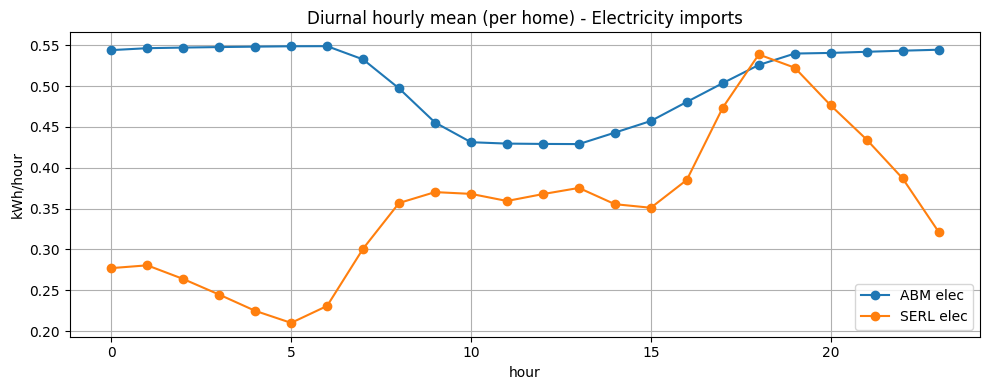

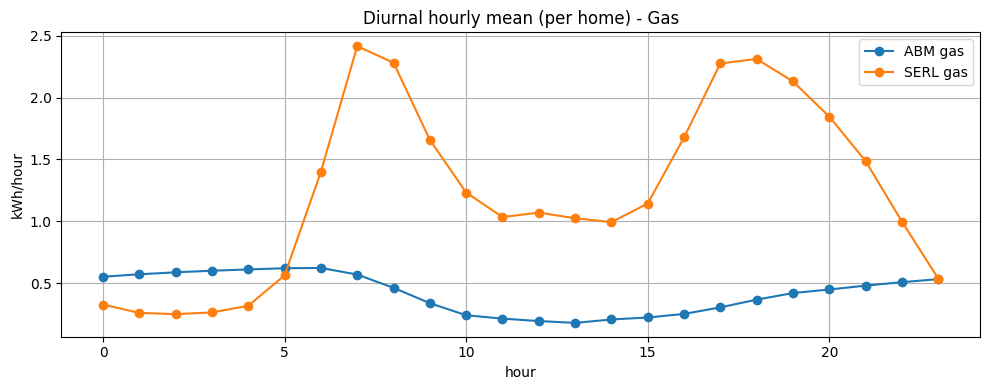

,hour,electric_kwh,gas_kwh,abm_elec_kwh_per_home,abm_gas_kwh_per_home,serl_elec_kwh_per_home,serl_gas_kwh_per_home
0,0.0,1632.253374,1654.485165,0.544084,0.551495,0.277031,0.325801
1,1.0,1639.332122,1713.233216,0.546444,0.571078,0.280461,0.258691
2,2.0,1641.642400,1761.319689,0.547214,0.587107,0.263730,0.248358
3,3.0,1643.480632,1799.514679,0.547827,0.599838,0.244609,0.262257
4,4.0,1644.986471,1830.715974,0.548329,0.610239,0.224736,0.316262


In [60]:
# ---- Compare ABM vs SERL marginal means ----

n_homes = len(wf_sample)
m_ts['hour'] = m_ts['timestamp'].dt.hour

# ABM per-home hourly mean (kWh/hour) aggregated by hour-of-day
abm_hourly = (m_ts.groupby('hour', as_index=False)
                .agg(electric_kwh=('total_electric_kwh','mean'), gas_kwh=('total_gas_kwh','mean')))

abm_hourly['abm_elec_kwh_per_home'] = abm_hourly['electric_kwh'] / n_homes
abm_hourly['abm_gas_kwh_per_home'] = abm_hourly['gas_kwh'] / n_homes

# SERL baseline (no seg3) diurnal hourly mean for same year
serl_base = hourly_mean_out[(hourly_mean_out['year'] == TARGET_YEAR)
                           & (hourly_mean_out['weekday_weekend'].astype(str) == 'both')
                           & (hourly_mean_out['heating_fuel'].astype(str) == 'All')
                           & (hourly_mean_out['has_pv'].astype(str) == 'No')
                           & (hourly_mean_out['seg3_var'].astype(str) == 'none')
                           & (hourly_mean_out['seg3_value'].astype(str) == 'none')].copy()

serl_e = serl_base[serl_base['quantity'].astype(str) == 'Electricity imports'][['hour','mean_kwh']].rename(columns={'mean_kwh':'serl_elec_kwh_per_home'})
serl_g = serl_base[serl_base['quantity'].astype(str) == 'Gas'][['hour','mean_kwh']].rename(columns={'mean_kwh':'serl_gas_kwh_per_home'})

cmp = abm_hourly.merge(serl_e, on='hour', how='left').merge(serl_g, on='hour', how='left')

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(cmp['hour'], cmp['abm_elec_kwh_per_home'], marker='o', label='ABM elec')
ax.plot(cmp['hour'], cmp['serl_elec_kwh_per_home'], marker='o', label='SERL elec')
ax.set_title('Diurnal hourly mean (per home) - Electricity imports')
ax.set_xlabel('hour'); ax.set_ylabel('kWh/hour'); ax.legend(); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(cmp['hour'], cmp['abm_gas_kwh_per_home'], marker='o', label='ABM gas')
ax.plot(cmp['hour'], cmp['serl_gas_kwh_per_home'], marker='o', label='SERL gas')
ax.set_title('Diurnal hourly mean (per home) - Gas')
ax.set_xlabel('hour'); ax.set_ylabel('kWh/hour'); ax.legend(); plt.tight_layout(); plt.show()

cmp.head(5)


## Run all seg3 plots

This will generate hourly/monthly/annual plots for every `seg3_var` for both electricity imports and gas.
By default it saves PNGs and does not display them inline.


In [61]:
# Generate plots for ALL seg3_var values
# This can create lots of figures. Recommended: set SAVE=True to write PNGs, and SHOW=False to avoid UI overload.

PLOT_YEAR = 2023
MAX_LINES = 8
SAVE = True
SHOW = False

PLOTS_DIR = OUT_DIR / 'plots_by_seg3'

seg3_vars = sorted({v for v in daily_targets['seg3_var'].astype(str).unique().tolist()} | {v for v in hourly_mean_out['seg3_var'].astype(str).unique().tolist()})
seg3_vars = [v for v in seg3_vars if v not in ('none', 'nan', '<NA>')]
print('seg3_vars:', seg3_vars)

for seg3 in seg3_vars:
    print('===', seg3, '===')

    # Electricity imports (PV matters)
    plot_hourly_profiles_for_seg3(
        year=PLOT_YEAR, seg3_var=seg3, quantity='Electricity imports', has_pv='No', max_lines=MAX_LINES,
        savepath=(PLOTS_DIR / seg3 / f'hourly_elec_{PLOT_YEAR}.png') if SAVE else None,
        show=SHOW,
    )
    plot_monthly_means_for_seg3(
        year=PLOT_YEAR, seg3_var=seg3, quantity='Electricity imports', has_pv='No', max_lines=MAX_LINES,
        savepath=(PLOTS_DIR / seg3 / f'monthly_elec_{PLOT_YEAR}.png') if SAVE else None,
        show=SHOW,
    )
    plot_annual_means_for_seg3(
        seg3_var=seg3, quantity='Electricity imports', has_pv='No', max_lines=MAX_LINES,
        savepath=(PLOTS_DIR / seg3 / 'annual_elec_2020_2023.png') if SAVE else None,
        show=SHOW,
    )

    # Gas (PV irrelevant; use has_pv='All' to maximise N)
    plot_hourly_profiles_for_seg3(
        year=PLOT_YEAR, seg3_var=seg3, quantity='Gas', has_pv='All', max_lines=MAX_LINES,
        savepath=(PLOTS_DIR / seg3 / f'hourly_gas_{PLOT_YEAR}.png') if SAVE else None,
        show=SHOW,
    )
    plot_monthly_means_for_seg3(
        year=PLOT_YEAR, seg3_var=seg3, quantity='Gas', has_pv='All', max_lines=MAX_LINES,
        savepath=(PLOTS_DIR / seg3 / f'monthly_gas_{PLOT_YEAR}.png') if SAVE else None,
        show=SHOW,
    )
    plot_annual_means_for_seg3(
        seg3_var=seg3, quantity='Gas', has_pv='All', max_lines=MAX_LINES,
        savepath=(PLOTS_DIR / seg3 / 'annual_gas_2020_2023.png') if SAVE else None,
        show=SHOW,
    )

print('Done. Plots in:', PLOTS_DIR)


seg3_vars: ['IMD_quintile', 'building_age', 'building_type', 'central_heating_type', 'currentEnergyRating', 'floor_area_m2', 'has_ev', 'num_bedrooms', 'num_occupants', 'region', 'temperature_band', 'tenure']
=== IMD_quintile ===
=== building_age ===
=== building_type ===
=== central_heating_type ===
=== currentEnergyRating ===
=== floor_area_m2 ===
=== has_ev ===
=== num_bedrooms ===
=== num_occupants ===
=== region ===
=== temperature_band ===
=== tenure ===
Done. Plots in: /Users/abeltran/Documents/GitHub/spdt_abm/data/serl_8963_targets/plots_by_seg3
